# Idea
this is a follow up on trend_forecast2.ipynb

## Data
I want to load the "interesting" subsets I have found:
- based on Flags of Events (Shock- Magnetic Obstacles)
- mased on orbital decay over 1 orbital period of GRACE-FO-1
and merge them into one dataset

## Forecasting Model

I want a forecasting model including
- ('orbital_decay')
- '|avg B|'
- 'F10.7 (LASP)'
- 'Bz GSE'
- 'Flow Speed (km/s'
- 'Temperature (K)'

but I want to test different models
- LinearRegression()
- Lasso()

to see the impact of regularisation

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utils.data_loader import load_parquet, find_repo_root
from pathlib import Path
import numpy as np
from utils.modeling import statistics, make_lags, make_multistep_target, aggregate_multistep_predictions

# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 8)
                 time  orbital_decay   |avg B|  F10.7 (LASP)    Bz GSE  \
0 2023-01-01 00:00:00        16.6730  5.630000         153.0 -0.960000   
1 2023-01-01 00:00:20        16.6730  5.633333         153.0 -0.426667   
2 2023-01-01 00:00:40        16.6735  5.636667         153.0  0.106667   
3 2023-01-01 00:01:00        16.6740  5.640000         153.0  0.640000   
4 2023-01-01 00:01:20        16.6740  5.633333         153.0  0.190000   

   Flow Speed (km/s  Temperature (K)  Kp (LASP)  
0        595.600000          80634.0      2.333  
1        595.600000          80634.0      2.333  
2        595.600000          80634.0      2.333  
3        595.600000          80634.0      2.333  
4        593.066667          82111.0      2.333  


## Subsets

In [2]:
def load_intervals(csv_paths):
    """Load start/end intervals from one or more CSV files."""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, parse_dates=["start", "end"])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def merge_intervals(df):
    """Merge overlapping time intervals."""
    # Sort intervals by start time
    df = df.sort_values("start").reset_index(drop=True)

    merged = []
    current_start = df.loc[0, "start"]
    current_end = df.loc[0, "end"]

    for i in range(1, len(df)):
        row_start = df.loc[i, "start"]
        row_end = df.loc[i, "end"]

        if row_start <= current_end:  
            # Overlapping or touching intervals → extend the end if needed
            current_end = max(current_end, row_end)
        else:  
            # No overlap → push current and reset
            merged.append((current_start, current_end))
            current_start = row_start
            current_end = row_end

    # Append final interval
    merged.append((current_start, current_end))

    return pd.DataFrame(merged, columns=["start", "end"])


csv_files = [
    find_repo_root() / Path("Analysis/modeling/subsets_eflag.csv"),
    find_repo_root() / Path("Analysis/modeling/subsets_meanstd.csv")
]

intervals_df = load_intervals(csv_files)
merged_df = merge_intervals(intervals_df)

### Illustrate where the "interesting" subsets are

In [3]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index)
# resample
df = df.resample('5min').mean()
# time delta in seconds
dt_seconds = (df.index[1] - df.index[0]).total_seconds()

In [4]:
df['e_flag'] = 0

t01 = pd.Timedelta(hours=24)  # extension before 0->1
t10 = pd.Timedelta(hours=12)  # extension after 1->0
# mo flags
interval_starts = pd.to_datetime(merged_df['start']).dropna()

interval_ends = pd.to_datetime(merged_df['end']).dropna()

intervals = list(zip(interval_starts, interval_ends))
for start, end in intervals:
    df.loc[(df.index >= start) & (df.index <= end), 'e_flag'] = 1

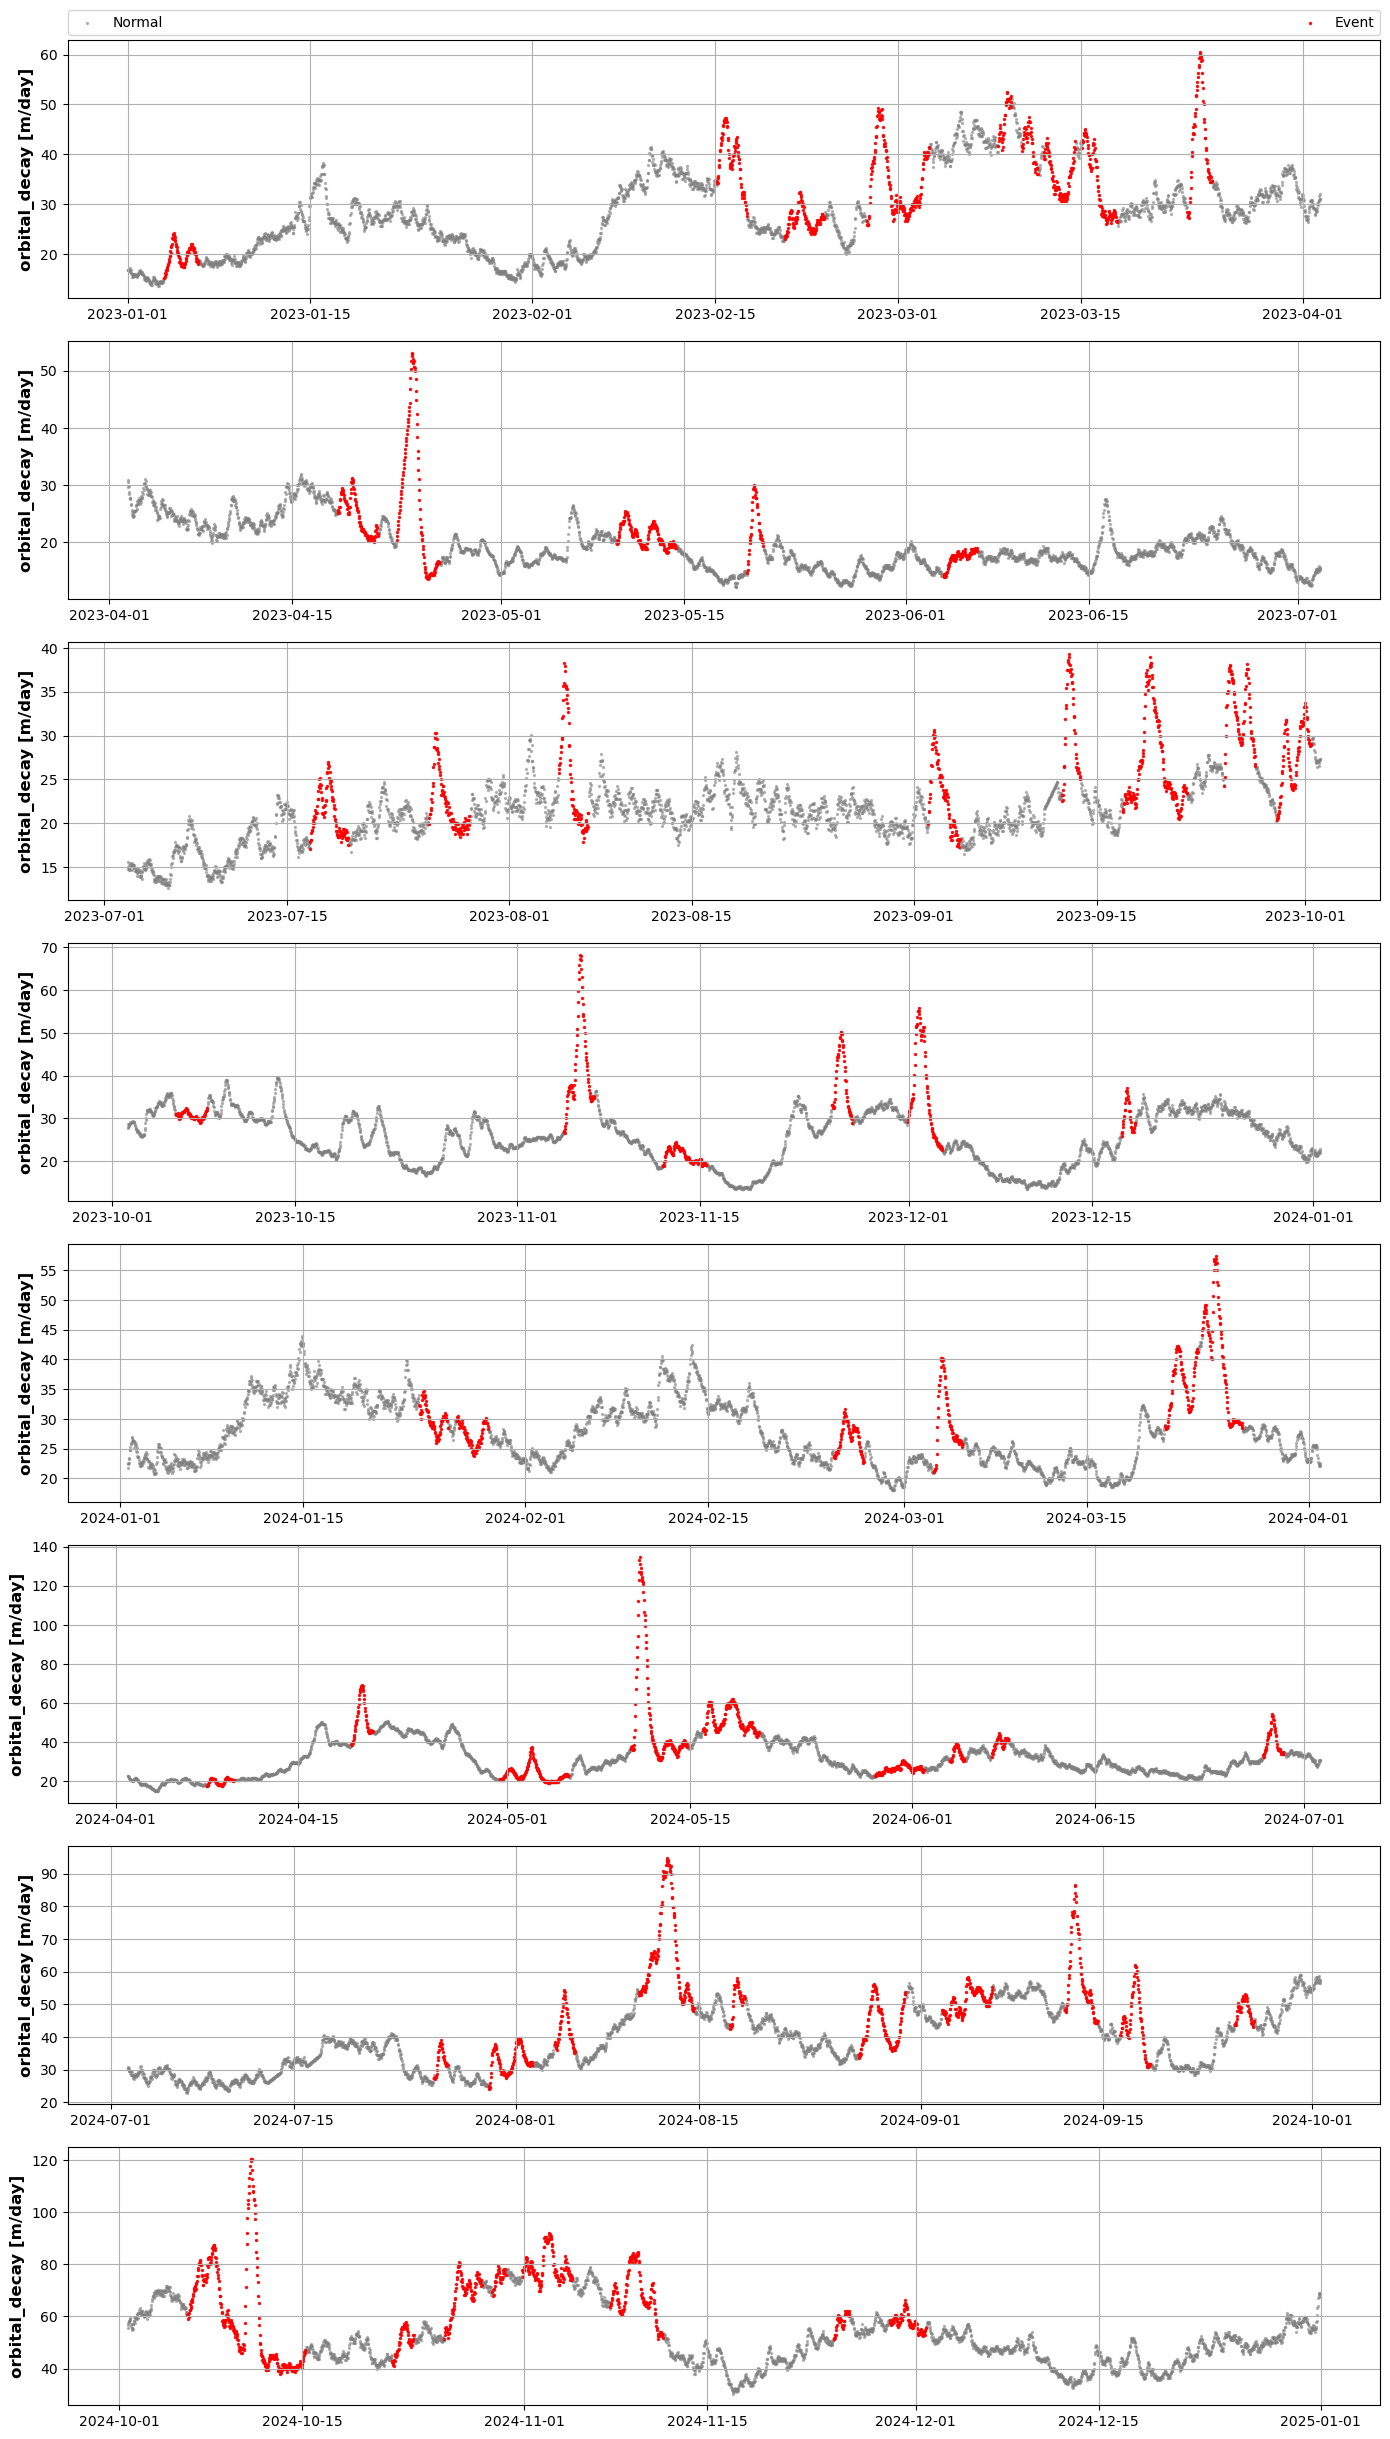

In [5]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    flagged   = chunk[chunk['e_flag'] == 1]
    unflagged = chunk[chunk['e_flag'] == 0]

    ax.scatter(
        unflagged.index,
        unflagged['orbital_decay'],
        s=2,
        color='gray',
        alpha=0.5,
        label='Normal'
    )

    ax.scatter(
        flagged.index,
        flagged['orbital_decay'],
        s=2,
        color='red',
        alpha=0.9,
        label='Event'
    )

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=4, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

### Load data into subsets

In [ ]:
from numpy.polynomial import Polynomial
from statsmodels.tsa.seasonal import STL

subsets = []

# polynomial coefficients for orbital period (minutes) as function of time (years since 2000)
p_list = [1.06605722e+02, -7.21846851e-09]
p = Polynomial(p_list)

for start, end in intervals:
    subset = df.loc[start-t01:end+t10]

    # daily means
    subset['od_daily_mean'] = subset['orbital_decay'].rolling('1D').mean()

    # compute orbital period and phase
    orbital_period = p(subset.index.astype(np.int64) / 1e9) * 60 # seconds
    # cumulative orbital cycles over time
    cycles = np.cumsum(1 / orbital_period) * dt_seconds   # because your sampling is every 20s
    # phase angle
    subset["orbital_period"] = orbital_period
    subset["phase"] = (2 * np.pi * cycles) % (2 * np.pi)
    subset["sin_phase"] = np.sin(subset.phase)
    subset["cos_phase"] = np.cos(subset.phase)

    # STL parameters
    mean_period_s = np.nanmedian(orbital_period)  # seconds per cycle
    period_samples = int(round(mean_period_s / dt_seconds))
    seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
    trend_jump = int(0.15 * 1.5 * (period_samples + 1))
    # stl = STL(subset["orbital_decay"], period=period_samples, robust=True)
    stl = STL(
        subset["orbital_decay"],
        period=period_samples,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
    )
    res = stl.fit()
    subset["osc_stl"] = res.seasonal
    subset["trend_stl"] = res.trend
    subset["resid_stl"] = res.resid
    # set variables
    subset["oscillation"] = subset["osc_stl"] + subset["resid_stl"]
    subset["trend"] = subset["trend_stl"]

    subsets.append(subset)


# Multioutput Model

In [8]:
hour = int(60 / (dt_seconds / 60))  # number of samples in one hour
lag_config_trend = {
    "od_daily_mean": {"lags": [24*hour]}, # we might not now the orbital decay rate, but we can estimate it from previous days
    "|avg B|": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "F10.7 (LASP)": {'lags': list(range(1, 24*hour, 6*hour)) + list(range(24*hour, 2*24*hour, 12*hour))},
    "Bz GSE": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "Flow Speed (km/s": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "Temperature (K)": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
}

X_trend_list = []
y_trend_list = []
n = 12  # hours ahead
y_stepsize = int(15 * (60 / dt_seconds)) # every 15 minutes

for subset in subsets:
    X_trend = make_lags(subset, lag_config_trend)

    y_trend = make_multistep_target(subset[['trend']].copy(), steps=int(n * 60 * (60 / dt_seconds)), stepsize=y_stepsize)

    # Shifting has created indexes that don't match. Only keep times for
    na_mask = X_trend.isna().any(axis=1) | y_trend.isna().any(axis=1)
    X_trend = X_trend[~na_mask]
    y_trend = y_trend[~na_mask]

    # Rename columns to avoid MultiIndex issues
    X_trend.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X_trend.columns]

    X_trend_list.append(X_trend)
    y_trend_list.append(y_trend)

## Split into training and test sets and Merge

In [9]:
no_test_subsets = 10

X_train = pd.concat(X_trend_list[:-no_test_subsets])
y_train = pd.concat(y_trend_list[:-no_test_subsets])
X_test = pd.concat(X_trend_list[-no_test_subsets:])
y_test = pd.concat(y_trend_list[-no_test_subsets:])

## Training

In [ ]:
from sklearn.linear_model import Lasso, LinearRegression, MultiTaskElasticNet
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scale and convert back to DataFrames
X_trend_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_trend_test_scaled = pd.DataFrame(
    scaler.transform(X_trend_test),
    index=X_trend_test.index,
    columns=X_trend_test.columns
)

NameError: name 'X_trend_train' is not defined